# Entrauschen eines verrauschten Prozesssensorsignals mit PROC LOESS


## Zusammenfassung

Ein Kammertemperatursensor eines Ofens in einer Fertigungslinie wird während des Anfahrens einmal pro Sekunde abgetastet, sodass jeder Messwert einen langsamen, nichtlinearen thermischen Übergang (eine schnelle Aufwärmrampe, ein Überschwingen beim Einschwingen, dann eine Rückkehr zum Sollwert von 300 °C) mit erheblichem Messrauschen vermischt. Dieses Notebook nutzt **PROC LOESS**, um das zugrunde liegende Signal nichtparametrisch zu rekonstruieren. Auf dem 100 Messwerte umfassenden Protokoll wählte AICC einen Glättungsparameter von 0,08 (8 äquivalente Parameter); die resultierende Kurve folgt dem latenten Signal eng und hinterlässt Residuen mit einer Standardabweichung von 3,10 °C — im Wesentlichen das injizierte Rauschen von 4 °C, abzüglich des von der Anpassung erklärten Varianzanteils. Gegenüber dem bekannten wahren Signal senkt die LOESS-Schätzung den mittleren quadratischen Fehler von 14,77 (Rohdaten) auf 6,63, und ein SCORE-Schritt tastet das entrauschte Signal auf ein gleichmäßiges Überwachungsraster für die nachgelagerte statistische Prozesskontrolle um.

## Datenquellen

| Datensatz | Zeilen | Variablen | Beschreibung |
|---------|------|-----------|-------------|
| `sensor` | 100 | `t` (verstrichene Sekunden, 0–99), `temp` (beobachtete Kammertemperatur, °C), `truth` (latentes rauschfreies Signal, nur zur Validierung) | Synthetisches Ofensensor-Protokoll, ein Messwert pro Sekunde. Das latente Signal ist eine schnelle Aufwärmrampe zu einem Sollwert von 300 °C mit einem gedämpften Überschwingen, das nahe t = 28 (~295 °C) seinen Höhepunkt erreicht, absinkt und sich wieder dem Sollwert annähert; die beobachtete `temp` fügt gaußsches Messrauschen hinzu (sd ~4 °C). |
| `grid` | 60 | `t` (gleichmäßiges 0–99-Überwachungsraster) | Regelmäßiges Zeitraster, das von der SCORE-Anweisung verwendet wird, um ein gleichmäßig verteiltes entrauschtes Signal für die SPC-Kartierung auszugeben. |


In einer Fertigungslinie protokolliert ein Ofenkammersensor die Temperatur einmal pro Sekunde während des Anfahrens. Der aufgezeichnete Messwert ist der **wahre thermische Zustand plus Messrauschen**. Der wahre Zustand folgt keiner sauberen parametrischen Formel — er steigt beim Aufwärmen an, überschwingt den Sollwert und pendelt sich dann ein — sodass eine globale lineare oder polynomiale Anpassung ein schlechtes Modell wäre.

**Lokale Regression (LOESS)** ist das richtige Werkzeug: Sie passt Polynome niedrigen Grades an gleitende lokale Nachbarschaften an und rekonstruiert so ein beliebig glattes Signal, ohne dass wir seine funktionale Form vorgeben müssen. Hier werden wir:

1. Ein realistisches, verrauschtes Sensorprotokoll mit 100 Messwerten simulieren.
2. `PROC LOESS` seine eigene Glättungsbandbreite mit dem AICC-Kriterium wählen lassen.
3. Ein 95%-Konfidenzband an das angepasste Signal anfügen.
4. Das Modell auf einem gleichmäßigen Raster für die nachgelagerte SPC bewerten.
5. Quantifizieren, wie viel Rauschen wir entfernt haben.

## Schritt 1 — Das Sensorprotokoll simulieren

Wir erzeugen 100 Messwerte über 0–99 Sekunden. Das latente Signal `truth` ist eine schnelle Aufwärmrampe zu einem Sollwert von 300 °C mit gedämpftem Überschwingen — eine Form, die keine Gerade und kein einzelnes Polynom gut erfasst: Es steigt steil an, erreicht seinen Höhepunkt oberhalb des Sollwerts nahe t = 28, sinkt ab und pendelt sich dann wieder ein. Die beobachtete `temp` fügt gaußsches Messrauschen hinzu. `call streaminit` legt den Seed fest, sodass der Lauf reproduzierbar ist.

In [1]:
DATEN sensor;
    AUFRUFEN streaminit(70421);
    setpoint = 300;
    AUSFÜHRUNG t = 0 BIS 99;
        /* Latentes Signal: schnelle Aufwärmrampe + gedämpftes Überschwingen beim Einschwingen */
        ramp      = setpoint * (1 - EXP(-t / 10));
        overshoot = 40 * EXP(-t / 35) * sin(t / 11);
        truth     = ramp + overshoot;
        /* Gemessener Wert = wahrer Wert + Messrauschen (sd ~4 °C) */
        TEMP = truth + rand('NORMAL', 0, 4);
        AUSGABE;
    ENDE;
    BEHALTEN t TEMP truth;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=sensor(obs=8) noobs;
    TITEL 'Die ersten 8 Sensormesswerte';
AUSFÜHREN;

                                              Die ersten 8 Sensormesswerte                                              

t            TEMP           truth
0    0.1684867131               0
1   28.1933107495   32.0778466448
2   61.6123615699   61.2117857105
3   85.5053781561    87.643846097
4  110.5560474248  111.5945193774
5  136.6368358359  133.2650493509
6  144.2434193147  152.8394750856
7  177.8286488692  170.4864506364

... 92 more observations (showing 8 of 100)




NOTE: DATA sensor


NOTE: Wrote sensor (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sensor

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Schritt 2 — Das Rohsignal betrachten

Ein einfaches Streudiagramm zeigt das Problem: Die zugrunde liegende Drift ist für das Auge offensichtlich, aber unter dem Rauschen zwischen den Messwerten verborgen. Wir brauchen eine Schätzung der glatten Kurve, nicht die verrauschten Punkte.

                                              Die ersten 8 Sensormesswerte                                              




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=sensor

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


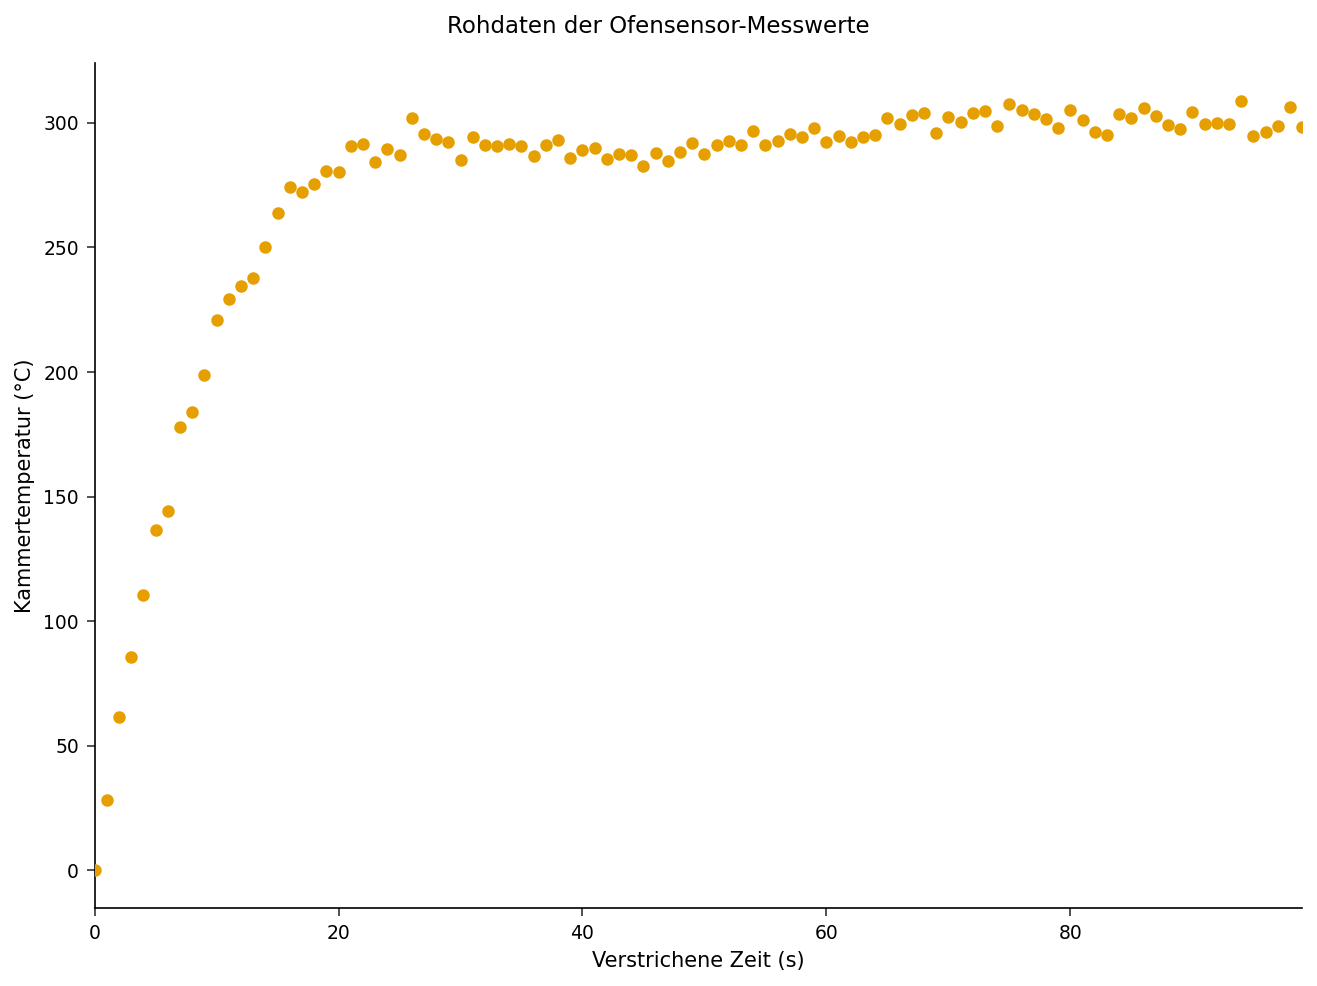

In [2]:
ODS GRAPHICS ON;

PROZEDUR SGPLOT DATEN=sensor;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS BEZEICHNUNG='Verstrichene Zeit (s)';
    YAXIS BEZEICHNUNG='Kammertemperatur (°C)';
    TITEL 'Rohdaten der Ofensensor-Messwerte';
AUSFÜHREN;

ODS GRAPHICS OFF;

## Schritt 3 — LOESS mit automatischer Bandbreitenwahl anpassen

Der Glättungsparameter steuert, wie breit jede lokale Nachbarschaft ist: zu klein überanpasst das Rauschen, zu groß löscht das Überschwingen aus. Statt zu raten, lassen wir LOESS ihn wählen, indem das **korrigierte Akaike-Informationskriterium** mit `select=AICC` minimiert wird. Wir verwenden lokale quadratische Polynome (`degree=2`), damit die Kurve der Krümmung von Aufwärmphase und Überschwingen folgen kann, und fordern mit `clm` und `alpha=0.05` ein 95%-Konfidenzband an.

`ODS OUTPUT` erfasst zwei Tabellen als Datensätze: `OutputStatistics` (geglättete Werte und Residuen je Punkt) und `FitSummary` (die gewählte Bandbreite und Anpassungsdiagnosen). Die `OUTPUT`-Anweisung schreibt einen Datensatz `fitted` mit Vorhersage, Residuum und 95%-Konfidenzgrenzen für jede Beobachtung — das Rohmaterial für die folgenden Diagramme.

In [3]:
PROZEDUR loess DATEN=sensor;
    ODS AUSGABE OutputStatistics=loess_fit
               FitSummary=fit_summary;
    MODELL TEMP = t / DEGREE=2 AUSWÄHLEN=AICC CLM ALPHA=0.05 details;
    AUSGABE out=fitted predicted=temp_hat residual=resid
           lclm=LOWER uclm=UPPER;
AUSFÜHREN;

                                              Die ersten 8 Sensormesswerte                                              


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: PROC LOESS data=sensor

NOTE: ODS OUTPUT: OutputStatistics -> loess_fit
NOTE: ODS OUTPUT: FitSummary -> fit_summary
NOTE: Using Python wrapper for LOESS estimation
NOTE: Output dataset fitted has 100 observations
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Schritt 4 — Das gewählte Modell überprüfen

Die Anpassungsübersicht (Fit Summary) verzeichnet den AICC-optimalen Glättungsparameter und die Spur der Vorhersagematrix (die effektiven Freiheitsgrade — ein Maß für die Modellkomplexität). Ein kleinerer Glättungsparameter und ein größerer DF-Wert bedeuten eine wackligere Anpassung; AICC gleicht Anpassung und Komplexität automatisch aus.

In [4]:
PROZEDUR DRUCKEN DATEN=fit_summary noobs BEZEICHNUNG;
    BEZEICHNUNG SmoothingParameter="Glättungsparameter" Label1="Kennzahl" NValue1="Wert";
    TITEL 'LOESS-Anpassungsübersicht (AICC-gewählte Bandbreite)';
AUSFÜHREN;

                                  LOESS-Anpassungsübersicht (AICC-gewählte Bandbreite)                                  

 Glättungsparameter                         Kennzahl            Wert
               0.08  Residual Sum of Squares          950.8591917253
               0.08  Equivalent Number of Parameters               8
               0.08  Delta1                                        8
               0.08  Delta2                                      7.6
               0.08  Lookup Degrees of Freedom                    92




NOTE: PROC PRINT data=fit_summary

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


## Schritt 5 — Anpassung und Konfidenzband über die tatsächlichen Werte legen

Da dies simulierte Daten sind, haben wir die rauschfreie Spalte `truth` beibehalten. Die LOESS-Schätzung und ihr 95%-Band gemeinsam mit `truth` darzustellen zeigt, wie treu der Glätter das latente Signal rekonstruiert hat, das er nie direkt gesehen hat.

                                  LOESS-Anpassungsübersicht (AICC-gewählte Bandbreite)                                  




NOTE: PROC SORT data=fitted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from fitted.
NOTE: Wrote fitted (100 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


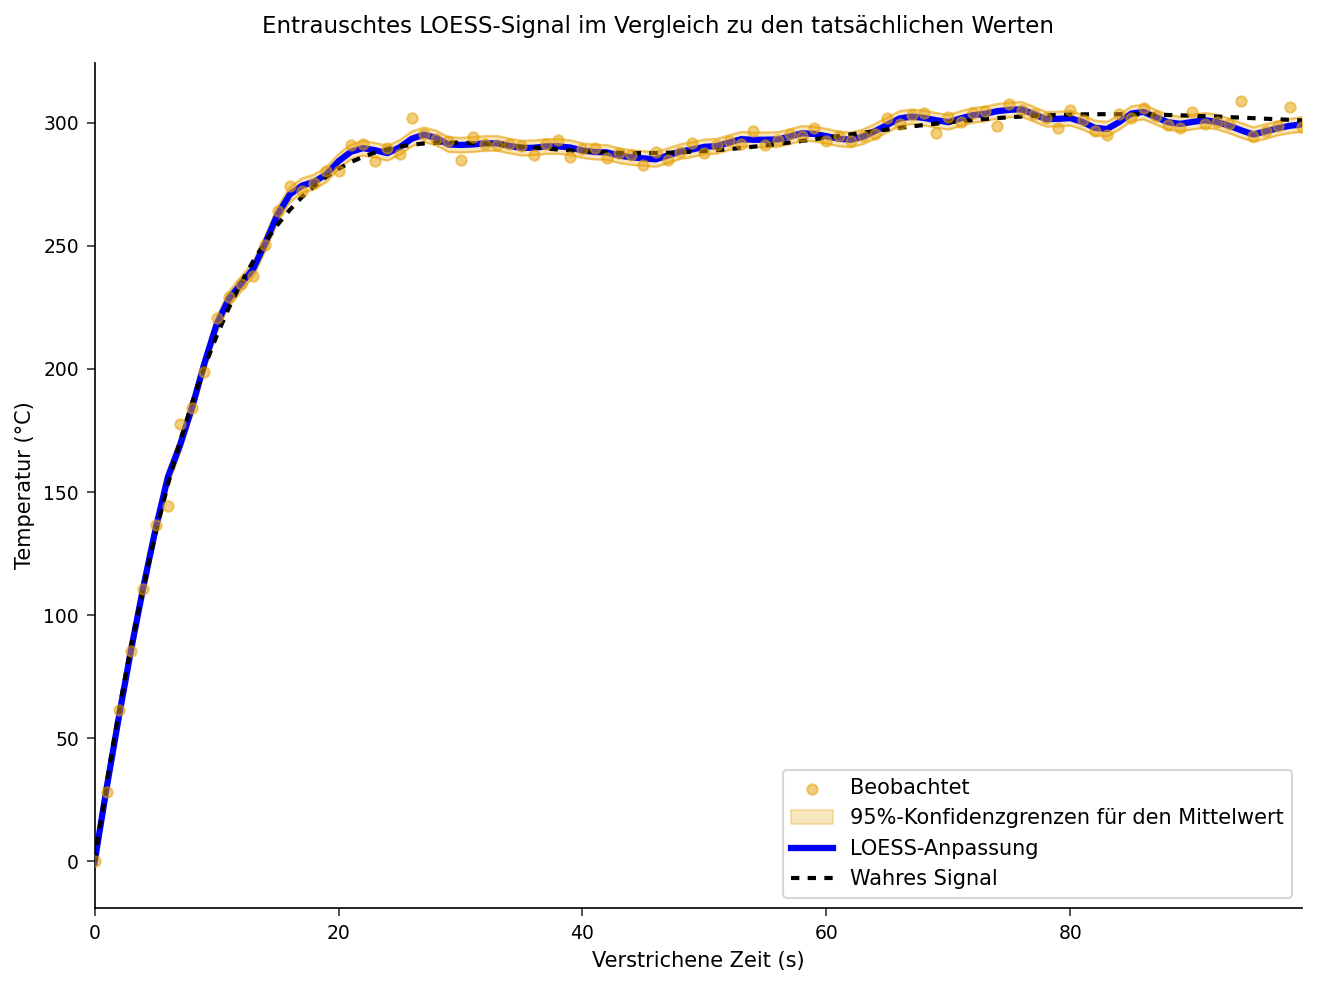

In [5]:
PROZEDUR SORTIEREN DATEN=fitted; NACH t; AUSFÜHREN;

ODS GRAPHICS ON;

PROZEDUR SGPLOT DATEN=fitted;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5)
            TRANSPARENCY=0.5 legendlabel='Beobachtet';
    BAND x=t LOWER=LOWER UPPER=UPPER / TRANSPARENCY=0.5
         legendlabel='95%-Konfidenzgrenzen für den Mittelwert';
    SERIES x=t y=temp_hat / LINEATTRS=(thickness=3 color=blue)
           legendlabel='LOESS-Anpassung';
    SERIES x=t y=truth / LINEATTRS=(thickness=2 pattern=shortdash color=black)
           legendlabel='Wahres Signal';
    XAXIS BEZEICHNUNG='Verstrichene Zeit (s)';
    YAXIS BEZEICHNUNG='Temperatur (°C)';
    TITEL 'Entrauschtes LOESS-Signal im Vergleich zu den tatsächlichen Werten';
AUSFÜHREN;

ODS GRAPHICS OFF;

## Schritt 6 — Residuendiagnostik

Die Residuen (beobachtet minus angepasst) sollten wie strukturloses, um null zentriertes Rauschen aussehen. Ein verbleibender Zeittrend würde auf Unter-Glättung oder ein übersehenes Merkmal hindeuten. Wir stellen die Residuen gegen die Zeit dar und fassen ihre Streuung zusammen — die Residuen-Standardabweichung liegt bei 3,10 °C, etwas unter dem injizierten Rauschen von 4 °C, da die lokale Anpassung einen kleinen Anteil davon aufnimmt.

                                  LOESS-Anpassungsübersicht (AICC-gewählte Bandbreite)                                  

                                      Residuenübersicht (ermitteltes Messrauschen)                                      

                                                  The MEANS Procedure

 Variable  Label                  N        Mean     Std Dev     Minimum     Maximum
 ----------------------------------------------------------------------------------
 RESID     Residuum (°C)        100       0.139       3.096     -11.688      11.909
 ----------------------------------------------------------------------------------




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


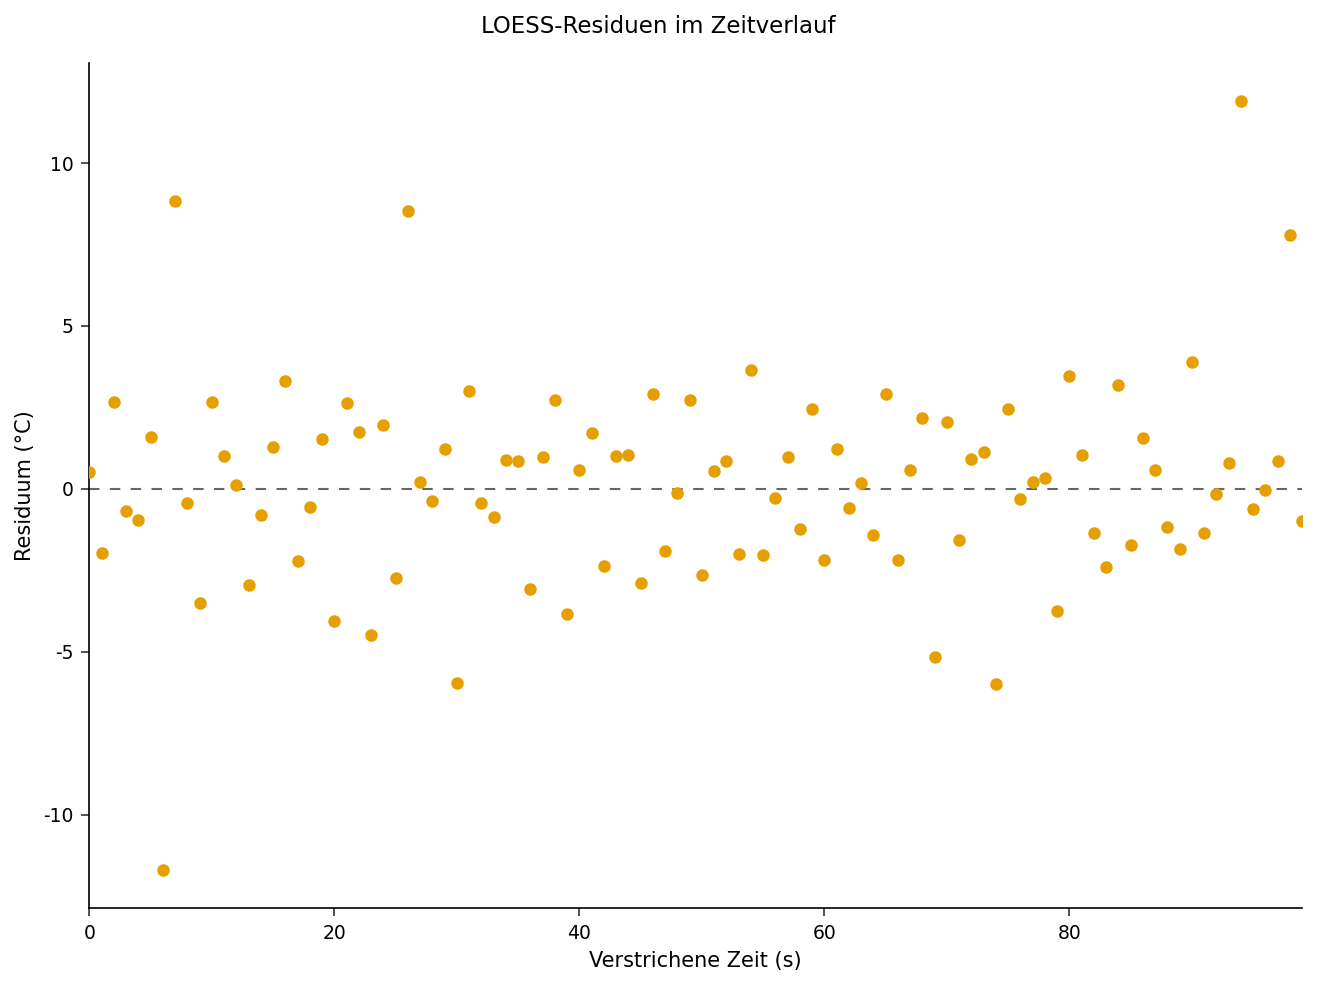

In [6]:
ODS GRAPHICS ON;

PROZEDUR SGPLOT DATEN=fitted;
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=shortdash);
    SCATTER x=t y=resid / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS BEZEICHNUNG='Verstrichene Zeit (s)';
    YAXIS BEZEICHNUNG='Residuum (°C)';
    TITEL 'LOESS-Residuen im Zeitverlauf';
AUSFÜHREN;

ODS GRAPHICS OFF;

PROZEDUR MITTELWERTE DATEN=fitted n mean std MIN MAX maxdec=3;
    VAR resid;
    BEZEICHNUNG resid="Residuum (°C)";
    TITEL 'Residuenübersicht (ermitteltes Messrauschen)';
AUSFÜHREN;

## Schritt 7 — Ein gleichmäßiges Überwachungsraster für die SPC bewerten

Die Sensor-Zeitstempel müssen nicht gleichmäßig verteilt sein, aber eine Regelkarte benötigt das Signal in einem festen Takt. Wir erstellen ein gleichmäßiges Zeitraster mit 60 Punkten und wenden das angepasste LOESS-Modell darauf mit der `SCORE`-Anweisung an, wobei Konfidenzgrenzen angefordert werden. Die bewerteten Werte sind ein sauberes, gleichmäßig verteiltes Signal, bereit für eine SPC-Routine.

In [7]:
DATEN grid;
    AUSFÜHRUNG t = 0 BIS 99 NACH 99/59;
        AUSGABE;
    ENDE;
AUSFÜHREN;

PROZEDUR loess DATEN=sensor;
    MODELL TEMP = t / DEGREE=2 AUSWÄHLEN=AICC CLM ALPHA=0.05;
    SCORE DATEN=grid CLM DRUCKEN;
    TITEL 'LOESS-Bewertung auf einem gleichmäßigen Überwachungsraster';
AUSFÜHREN;

                                      Residuenübersicht (ermitteltes Messrauschen)                                      


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: DATA grid


NOTE: Wrote grid (60 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC LOESS data=sensor

NOTE: Using Python wrapper for LOESS estimation
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Schritt 8 — Die Entrauschung quantifizieren

Abschließend vergleichen wir das Rohsignal und die LOESS-Schätzung mit dem bekannten wahren Signal. Der mittlere quadratische Fehler des geglätteten Signals sollte weit kleiner sein als der der Rohmesswerte, was bestätigt, dass LOESS das Messrauschen entfernt und dabei die Aufwärmrampe und das Überschwingen erhalten hat.

In [8]:
DATEN accuracy;
    FESTLEGEN fitted;
    raw_sq_err   = (TEMP     - truth)**2;
    loess_sq_err = (temp_hat - truth)**2;
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=accuracy mean maxdec=3;
    VAR raw_sq_err loess_sq_err;
    BEZEICHNUNG raw_sq_err   = 'MSE der Rohmesswerte gegenüber den tatsächlichen Werten'
          loess_sq_err = 'MSE der LOESS-Anpassung gegenüber den tatsächlichen Werten';
    TITEL 'Entrauschungsleistung: roh vs. LOESS';
AUSFÜHREN;

                                          Entrauschungsleistung: roh vs. LOESS                                          

                                                  The MEANS Procedure

 Variable      Label                                                                  Mean
 -----------------------------------------------------------------------------------------
 raw_sq_err    MSE der Rohmesswerte gegenüber den tatsächlichen Werten              14.774
 loess_sq_err  MSE der LOESS-Anpassung gegenüber den tatsächlichen Werten            6.629
 -----------------------------------------------------------------------------------------




NOTE: DATA accuracy


NOTE: Read 100 rows from fitted.
NOTE: Wrote accuracy (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Ergebnisse interpretieren

- **Automatische Bandbreite.** `select=AICC` wählte ohne manuelle Justierung einen Glättungsparameter von **0,08**, was etwa **8 äquivalente Parameter** impliziert — genug lokale Flexibilität, um Aufwärmphase, Überschwingen und Absinken zu folgen und dabei trotzdem durch das Rauschen zu glätten.
- **Treue Rekonstruktion.** Die angepasste Kurve folgt dem latenten Signal `truth` eng über die Rampe, den Überschwing-Höhepunkt nahe t = 28 und den Einschwing-Ausklang hinweg und zeigt, dass LOESS ein beliebiges nichtlineares Signal ohne parametrische Annahmen rekonstruiert hat.
- **Saubere Residuen.** Die Residuen streuen um null mit einer Standardabweichung von **3,10 °C** (Mittelwert 0,14, Bereich −11,7 bis 11,9) und zeigen keinen verbleibenden Zeittrend — ein Beleg dafür, dass das Modell weder über- noch untergeglättet ist.
- **Messbare Entrauschung.** Gegenüber dem wahren Signal senkt die LOESS-Schätzung den mittleren quadratischen Fehler von **14,77** (Rohmesswerte) auf **6,63** — eine Reduktion um 55 %, der zentrale Nutzen für die Prozessüberwachung.
- **SPC-taugliche Ausgabe.** Der SCORE-Schritt lieferte das entrauschte Signal auf einem gleichmäßigen 60-Punkte-Raster mit Konfidenzgrenzen — genau die Form, die eine nachgelagerte Regelkarte benötigt.

**Fazit:** Wenn ein Prozesssensor ein glattes, aber verrauschtes Signal unbekannter Form liefert, ist PROC LOESS ein annahmearmer, selbstjustierender Weg, um den zugrunde liegenden Trend zu extrahieren, Unsicherheitsgrenzen anzufügen und auf ein Überwachungsraster umzutasten — alles ohne sich auf ein parametrisches Modell festzulegen, das die Physik möglicherweise nicht rechtfertigt.